##### NB
- You might need to run `pip install tensorflow-addons` ´to use  `f1_score`.

# Compulsory Assignment 2: Convolutional neural networks

Please fill out the the group name, number, members and optionally the name below.

**Group number**: 2 \
**Group member 1**: Simen Roko Krogstie\
**Group member 2**: Kristian Mathias Røhne \
**Group member 3**: Erling Hamil Mysen \
**Group name (optional)**: The Three (Musk)eters

Make sure that the group name given in the assignment is the same that you use on the Kaggle Leaderboard.

# Assignment Submission
To complete this assignment answer the relevant questions in this notebook and write the code required to implement the relevant models. The assignment is submitted by handing in this notebook as an .ipynb file and as a .pdf file. In addition, you are required to submit at least one test prediction to the Kaggle leaderboard that is better than the *BEAT ME* score.

NOTE: Remember to go through the rules given in the lecture "Introduction to compulsory assignments", as there are many do's and dont's with regard to how you should present the work you are going to submit. 

# Introduction 
This assignment will start with classifying handwritten digits from the MNIST dataset, used in the voluntary assignment and the first compulsory assignment. The second part of this task will revolve around classifying the open-source Fashion-MNIST dataset.



## Fashion-MNIST

The Fashion-MNIST is a dataset created from Zlalando's articile images(https://github.com/zalandoresearch/fashion-mnist/blob/master/README.md). The dataset consits of 70,000 labels images in 28x28 grayscale image labeld from 0 to 10. The goal of the Fashion-MNIST to work as a harder version of the handletter dataset MNIST. The Github repo for the dataset descripte the dataset to be:
- "intend Fashion-MNIST to serve as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms."


<center><img src="fashion-mnist-sprite.png" width="500" height="400"></center>


## Assignment structure

1. Part 1: Implementing LeNet5 for classifying MNIST.
2. Part 2: Designing your own CNN for classifying Fashion-MNIST

## Submissions to the Kaggle leaderboard
Use the following code to create the `submission.csv` file that you can submit to the Kaggle leaderboard. 

```python
prediction = model.predict(X_test)
flat_prediction = np.argmax(prediction, axis=1) # Flatten softmax predictions
submissionDF = pd.DataFrame()
submissionDF['ID'] = range(len(flat_prediction)) # The submission csv file must have an row index column called 'ID'
submissionDF['Prediction'] = flat_prediction
submissionDF.to_csv('submission.csv', index=False) # Remember to store the dataframe to csv without the nameless index column.
```

## Library imports

In [8]:
# Feel free to add or remove libraries as you want
import time

import numpy as np
import pandas as pd
import h5py

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow.keras as ks

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.losses import CategoricalCrossentropy

from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.metrics import Accuracy
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix


SEED = 458
RNG = np.random.default_rng(SEED) # Random number generator

from utilities import *

# Part 1: CNN for classifying the MNIST dataset

## Loading MNIST

In [9]:
datasets = load_mnist(verbose=0)
X_train, y_train = datasets['X_train'], datasets['y_train']
X_val,   y_val   = datasets['X_val'],   datasets['y_val']
X_test,  y_test  = datasets['X_test'],  datasets['y_test']

X_train = np.concatenate([X_train, X_val], axis=0)
y_train = np.concatenate([y_train, y_val], axis=0).astype('int32')

del datasets, X_val, y_val # Good to reduce uneccesary RAM usage

## Preprocessing

In [10]:
# Reshape data to account for color channel
X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)

# Normalizing input between [0,1]
X_train = X_train.astype("float32")/np.max(X_train)
X_test  = X_test.astype("float32")/np.max(X_test)

# Converting targets from numbers to categorical format
y_train = ks.utils.to_categorical(y_train, len(np.unique(y_train)))
y_test  = ks.utils.to_categorical(y_test, len(np.unique(y_test)))

## Task 1.1: Build a CNN network with the LeNet5 architecture

##### Implement LeNent5 architecture according to the following specifications: 

--------------------------
The LeNet architecture takes a 28x28xC image as input, where C is the number of color channels. Since MNIST images are grayscale, C is 1 in this case.

**Layer 1 - Convolution (5x5):** The output shape should be 28x28x6. **Activation:** ReLU. 

**MaxPooling:** The output shape should be 14x14x6.

**Layer 2 - Convolution (5x5):** The output shape should be 10x10x16. **Activation:** ReLU. 

**MaxPooling:** The output shape should be 5x5x16.

**Flatten:** Flatten the output shape of the final pooling layer such that it's 1D instead of 3D.  You may need to use tf.reshape.

**Layer 3 - Fully Connected:** This should have 120 outputs. **Activation:** ReLU.

**Layer 4 - Fully Connected:** This should have 84 outputs. **Activation:** ReLU.

**Layer 5 - Fully Connected:** This should have 10 outputs. **Activation:** softmax.

--------------------------


##### Compile the network with the
* `tf.keras.losses.CategoricalCrossentropy` loss function
* the `adam` optimizer 
* with the `accuracy` metric and (your own implementation of the) F1-score metric.

In [11]:

model = Sequential([
    Conv2D(6, (5, 5), activation='relu', input_shape=(28, 28, 1), padding='same'),
    MaxPool2D(pool_size=(2, 2), strides=2),
    Conv2D(16, (5, 5), activation='relu'),
    MaxPool2D(pool_size=(2, 2), strides=2),
    Flatten(input_shape=(5, 5, 16)),
    Dense(120, activation='relu'),
    Dense(84, activation='relu'),
    Dense(10, activation='softmax')
])
   

/opt/anaconda3/envs/DAT300/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/DAT300/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
def f1_score(y_true, y_pred):
    # Convert predicted probabilities to binary predictions for each class (multi-label).
    y_pred = tf.round(y_pred)
    # Calculate precision for each class.
    precision = tf.reduce_sum(tf.cast(y_true * y_pred, 'float'), axis=0) / (tf.reduce_sum(tf.cast(y_pred, 'float'), axis=0) + tf.keras.backend.epsilon())
    # Calculate recall for each class. 
    recall = tf.reduce_sum(tf.cast(y_true * y_pred, 'float'), axis=0) / (tf.reduce_sum(tf.cast(y_true, 'float'), axis=0) + tf.keras.backend.epsilon())
    # Calculate F1 score for each class.
    f1 = 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())
    
    # Return mean F1 score across all classes
    return tf.reduce_mean(f1)  

In [13]:
model.compile(
    optimizer ='adam',
    loss = CategoricalCrossentropy(),
    metrics = ['accuracy', f1_score]
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

### Task 1.1.2 Train network

Train the network with a 
* batch size of 64 samples
* for 20 epochs
* 1/8 validation split

In [15]:
# Training the model

start_time = time.time()

history = model.fit(
    X_train, y_train,
    batch_size = 64,
    epochs = 20, 
    validation_split = 1/8
)

end_time = time.time()

model_1_training_time = end_time - start_time

Epoch 1/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8417 - f1_score: 0.7659 - loss: 0.5268 - val_accuracy: 0.9715 - val_f1_score: 0.9673 - val_loss: 0.0951
Epoch 2/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9749 - f1_score: 0.9718 - loss: 0.0778 - val_accuracy: 0.9821 - val_f1_score: 0.9785 - val_loss: 0.0603
Epoch 3/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9843 - f1_score: 0.9820 - loss: 0.0497 - val_accuracy: 0.9847 - val_f1_score: 0.9817 - val_loss: 0.0537
Epoch 4/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9890 - f1_score: 0.9866 - loss: 0.0349 - val_accuracy: 0.9832 - val_f1_score: 0.9806 - val_loss: 0.0554
Epoch 5/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9906 - f1_score: 0.9882 - loss: 0.0283 - val_accuracy: 0.9812 - val_f1_score: 0.9778 - val_loss: 0.0607
Epoch 6/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9917 - f1_score: 0.9894 - loss: 0.0256 - val_accuracy: 0.9868 - val_f1_score: 0.9847

In [16]:
print(f'{model_1_training_time:.5f} seconds')

125.99176 seconds


## Task 1.2 Evaluaiton
### Task 1.2.1 Plot training history and evaluate on test dataset

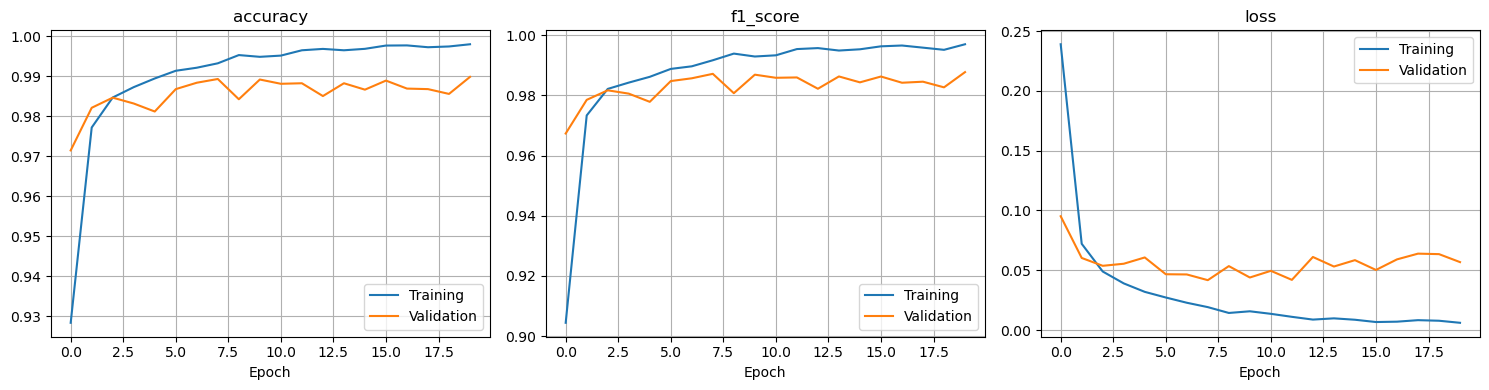

In [17]:
plot_training_history(history)


### Task 1.2.2 Evaluate on the test dataset

In [18]:
## SE OVER AT DU HAR GJORT ALT RIKTIG

# Evaluating LeNet-5 on the test data.

test_accuracy, test_f1_score, test_loss = model.evaluate(X_test, y_test)
print(f'LeNet-5 Accuracy: {test_accuracy:.5f}, LeNet-5 F1-score: {test_f1_score:.5f}, LeNet-5 loss: {test_loss}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9895 - f1_score: 0.9557 - loss: 0.0510
LeNet-5 Accuracy: 0.04047, LeNet-5 F1-score: 0.99100, LeNet-5 loss: 0.9638148546218872


### Task 2.2.3 Create a confution matrix for both traing and testing data
- Does the test data and train data predikt the same items wrong?

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


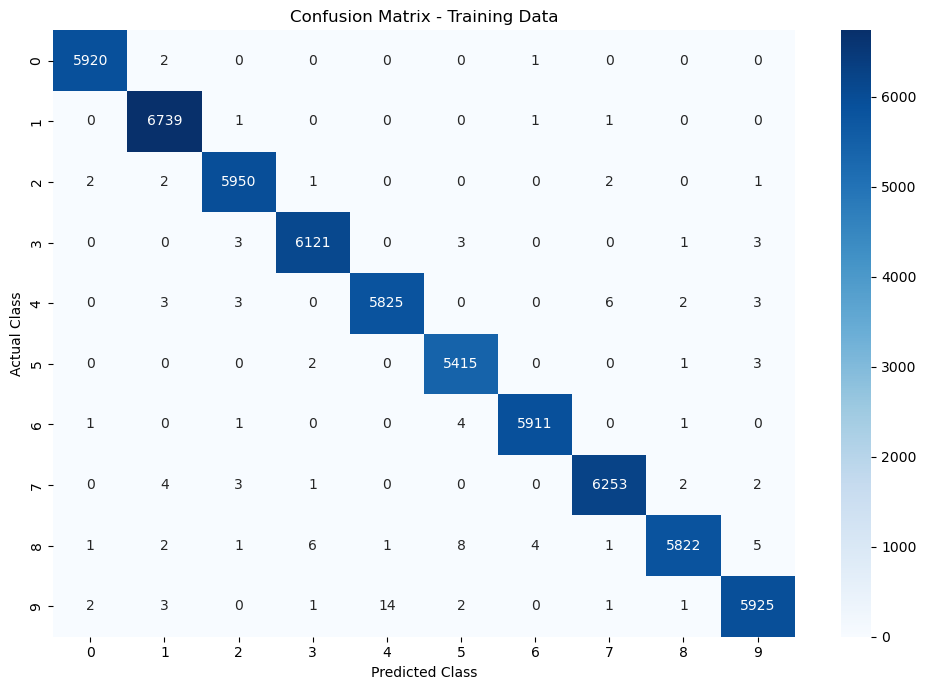

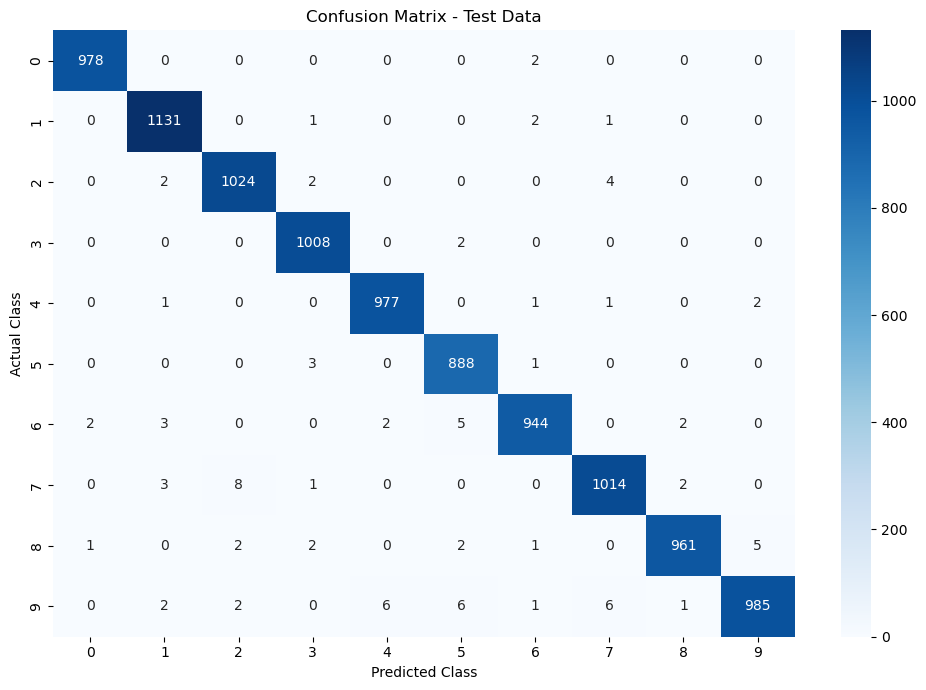

In [19]:
## HER MÅ DU KOMMENTERE MER OG SVARE PÅ SPØRSMÅL


y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Convert probabilities to class labels
y_train_pred_classes = np.argmax(y_train_pred, axis=1)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)

y_train_true = np.argmax(y_train, axis=1)
y_test_true = np.argmax(y_test, axis=1)

# Compute confusion matrix for training data
train_cm = confusion_matrix(y_train_true, y_train_pred_classes)

# Compute confusion matrix for test data
test_cm = confusion_matrix(y_test_true, y_test_pred_classes)

# Function to plot confusion matrix
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.show()

# Plot confusion matrix for training data
plot_confusion_matrix(train_cm, "Confusion Matrix - Training Data")

# Plot confusion matrix for test data
plot_confusion_matrix(test_cm, "Confusion Matrix - Test Data")

The training and test data ...

## Task 2.3: MNIST discussion

**Task 2.3.1: What is overfititng and how does it ocure during training of the LeNet-5 model**

**Task 2.3.2: What is ReLU and Leaky ReLU, what is their derivative and how does their derative solve the vanesting gradient problem?**

**Task 2.3.3: Calculate the Number of Trainable Parameters and the Output Shape of Feature Maps for LeNet-5 at Each Layer**


**Answer 2.3.1:** \
Overfitting is when a model performs very well on the training data, but fails to generalize on unseen data such as the validaiton and test data. That happens the model is too complex and is memorizing irrelevant details from the trainingdata, such as noise, and dont understand the trainingdatas underlying patterns. From the training history plot we see that both accuracy and F1-score from the training is increasing, while it is stagnating during the evaluation. We also see that the model gets better at minimizing the loss during the training, but the loss stops decreasing during the evaluation. During epoch 11 it even starts increasing, and the model is therefore overfitting on the training data. 


**Answer 2.3.2:** \
ReLU is an activation function commonly used in neural networks and deep learning. It keeps positive input values, and zeros out negative values. That is; f(x) = (x if x > 0, 0 if x <= 0). 
The derivative of ReLU is f'(x) = (1 if x > 0, 0 if x <= 0) such that the gradient is 1 for positive inputs, and 0 for negative inputs. This ensures that the gradients do not diminish during backpropagation, thus solving "the vanishing gradient problem". However, with ReLU we have "the dying ReLU problem", which is, that if there are only negative inputs, all the gradients will be 0 and the weights will not update.

Leaky ReLU is a modified version of the ReLU activaiton function. The functions can be written as f(x) = (x if x > 0, a*x if x <= 0). Instead of zeroing out the negative inputs, it outputs a small negative value. The gradient for negative values will therefore be a small non-zero value. The derivative can be written as f'(x) = (1 if x > 0, a if x <= 0).
Leaky ReLU solves therefore both "the vanishing gradient problem" and "the dying ReLU problem" by ensuring there is a small gradient flowing throught the network also for negative inputs.




**Answer 2.3.3:** \
Layer 1: Fyll ut her ... \
Layer 2: Fyll ut her ... \
Layer 3: Fyll ut her ... \
Layer 4: Fyll ut her ... \
Layer 5: Fyll ut her ... 

# Task 2: CNN for classifying the Fashion-MNIST dataset

In this task you shall implement a CNN model, and train it to classify the images in the Fashion-MNIST dataset.

## Importing Fashion-MNIST

- Filename: `Fashion_MNIST.h5`

In [247]:
FILE_PATH = "Fashion_MNIST.h5" # If data is in same directory as Jypyter File

labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot" 
}

In [248]:
with h5py.File(FILE_PATH,'r') as f:
    print('Datasets in file:', list(f.keys()))
    X_train = np.asarray(f['train_images'])
    y_train = np.asarray(f['train_labels'])
    X_test  = np.asarray(f['test_images'])
    print('Nr. train images: %i'%(X_train.shape[0]))
    print('Nr. test images: %i'%(X_test.shape[0]))

Datasets in file: ['test_images', 'train_images', 'train_labels']
Nr. train images: 59500
Nr. test images: 10500


## Task 2.1: Preprocess the data
Preprocess the data as you see fit

In [249]:
# Reshape data to account for color channel
X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)

# Normalizing input between [0,1]
X_train = X_train.astype("float32")/np.max(X_train)
X_test  = X_test.astype("float32")/np.max(X_test)

# Converting targets from numbers to categorical format
y_train_cat = ks.utils.to_categorical(y_train, len(np.unique(y_train)))
y_test_cat  = ks.utils.to_categorical(y_test, len(np.unique(y_test)))

## Task 2.2: Visualize the dataset
Plot a few samples images and the distrbution of classes in the data. 

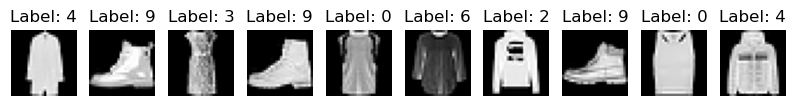

In [250]:
def plot_sample_images(images, labels, num_samples=10):
    plt.figure(figsize=(10, 2))
    
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(np.squeeze(images[i]), cmap='gray') # No need to squeeze
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    
    plt.show()

# Plot 10 sample images
plot_sample_images(X_train, y_train, num_samples=10)


/var/folders/sj/p7jz762n09j7jz2k9h7bd_y80000gn/T/ipykernel_9854/419600753.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=df_labels, palette='coolwarm')


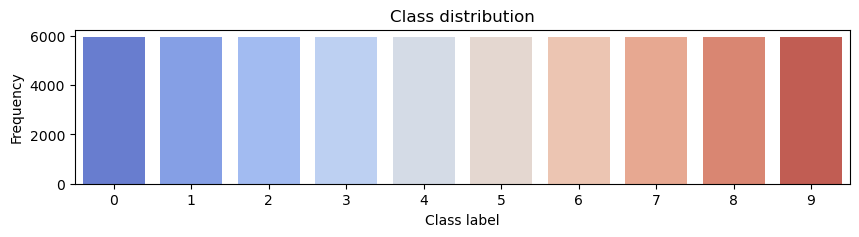

In [251]:
def class_distribution(labels):
    df_labels = pd.DataFrame(labels, columns=['Label'])
    
    plt.figure(figsize=(10, 2))
    sns.countplot(x='Label', data=df_labels, palette='coolwarm')
    plt.title('Class distribution')
    plt.xlabel('Class label')
    plt.ylabel('Frequency')
    plt.show()

class_distribution(y_train)

We can clearly see that the class distribution is equal in the training data. 

## Task 2.3: Build a CNN for Classifying the Fashion-MNIST Dataset
Build a CNN model and beat the "Beat Me" score on Kaggle.

- Experiment with different kernel sizes, strides, and types/number of layers.
- Don’t overcomplicate it; focues on as grounds for discussion when you make the models.
Tips: When you make changes to the model, save some earlier iterations.
You need only one model scored higher than "Beat Me."

In [252]:
KaggleModel = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), padding='same'),     # 64 filters
    MaxPool2D(pool_size=(2, 2), strides=2),
    
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPool2D(pool_size=(2, 2), strides=2),
    
    Flatten(),
    Dropout(0.5),                  
    Dense(10, activation='softmax'),
])


# Compile model_4
KaggleModel.compile(
    optimizer= Adam(learning_rate=0.001),
    loss= CategoricalCrossentropy(),
    metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
# Train model_4
KaggleModel_history= KaggleModel.fit(
    X_train, y_train_cat, 
    batch_size = 82,           #64                        
    epochs = 15,                           
    validation_split = 1/6,
    callbacks = [es]
)  

Epoch 1/15


/opt/anaconda3/envs/DAT300/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


605/605 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6808 - loss: 0.8956 - val_accuracy: 0.8470 - val_loss: 0.4361
Epoch 2/15
605/605 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8405 - loss: 0.4404 - val_accuracy: 0.8773 - val_loss: 0.3555
Epoch 3/15
605/605 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8586 - loss: 0.3956 - val_accuracy: 0.8837 - val_loss: 0.3303
Epoch 4/15
605/605 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8724 - loss: 0.3652 - val_accuracy: 0.8918 - val_loss: 0.3099
Epoch 5/15
605/605 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8794 - loss: 0.3396 - val_accuracy: 0.8967 - val_loss: 0.2933
Epoch 6/15
605/605 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8826 - loss: 0.3279 - val_accuracy: 0.9020 - val_loss: 0.2805
Epoch 7/15
605/605 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8864 - loss: 0.3125 - val_accuracy: 0.9018 - val_loss: 0.2744
Epoch 8/15
605/605 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8921 - loss: 0.2996 - val_accuracy: 0.90

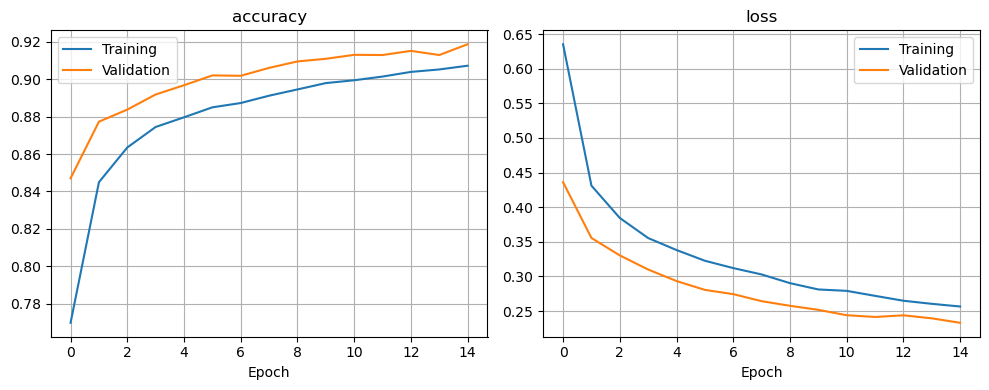

In [253]:
plot_training_history(KaggleModel_history)

## Task 2.4: Evaluate your best model on the test dataset and submit your prediction to the Kaggle leaderboard

In [184]:
Kaggle_model_prediction = KaggleModel.predict(X_test)
flat_Kaggle_model_prediction_prediction = np.argmax(Kaggle_model_prediction, axis=1)
submissionKaggle = pd.DataFrame()
submissionKaggle['ID'] = range(len(flat_Kaggle_model_prediction_prediction))
submissionKaggle['Prediction'] = flat_Kaggle_model_prediction_prediction
submissionKaggle.to_csv('KaggelSubmission_7.csv', index=False)

329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


# Task 2.5: Fashion-MNIST Discussion

### Task 3.5.1
- Feel Free to experimant on acitecture
- Comment on the choice of layers and hyper paramters. 
    - Did you find some different results in changing a hyer paramter or add/remove a layer.
